# Feature Engineering Methods

# Create Features

In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("data/cleaned_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

In [3]:
df

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0
...,...,...
449,2014-03-27,328.0
450,2014-03-28,523.0
451,2014-03-29,647.0
452,2014-03-30,599.0


In [4]:
# Lag features (per store and item)
df['lag_1'] = df['unit_sales'].shift(1)
df['lag_7'] = df['unit_sales'].shift(7)
df['lag_30'] = df['unit_sales'].shift(30)

In [5]:
df['unit_sales']

0      582.0
1      310.0
2      338.0
3      654.0
4      979.0
       ...  
449    328.0
450    523.0
451    647.0
452    599.0
453    415.0
Name: unit_sales, Length: 454, dtype: float64

In [6]:
# Rolling statistics
df['rollings_avg_2'] = df["unit_sales"].rolling(window=2).mean().shift(1)


In [7]:

df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


In [8]:
df

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2,2013-01-04,338.0,310.0,NaN,NaN,446.0,4,0
3,2013-01-05,654.0,338.0,NaN,NaN,324.0,5,1
4,2013-01-06,979.0,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0,412.0,3,0
450,2014-03-28,523.0,328.0,456.0,388.0,380.0,4,0
451,2014-03-29,647.0,523.0,567.0,587.0,425.5,5,1
452,2014-03-30,599.0,647.0,603.0,346.0,585.0,6,1


In [9]:
#df.to_csv("../data/feature_engineered_timeseries.csv", index=False)

# ML Part

In [10]:
split_date = '2014-01-01'
train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

In [11]:
test

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
364,2014-01-01,436.0,436.0,365.0,421.0,515.5,2,0
365,2014-01-02,589.0,436.0,418.0,493.0,436.0,3,0
366,2014-01-03,474.0,589.0,419.0,454.0,512.5,4,0
367,2014-01-04,767.0,474.0,499.0,265.0,531.5,5,1
368,2014-01-05,1203.0,767.0,552.0,388.0,620.5,6,1
...,...,...,...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0,412.0,3,0
450,2014-03-28,523.0,328.0,456.0,388.0,380.0,4,0
451,2014-03-29,647.0,523.0,567.0,587.0,425.5,5,1
452,2014-03-30,599.0,647.0,603.0,346.0,585.0,6,1


In [12]:
# Define target variable (unit_sales) and features
X_train = train.drop('unit_sales', axis=1)
X_train = X_train.drop('date', axis=1)
y_train = train['unit_sales']

X_test = test.drop('unit_sales', axis=1)
X_test = X_test.drop('date', axis=1)
y_test = test['unit_sales']

In [13]:
X_train

,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,NaN,NaN,NaN,NaN,2,0
1,582.0,NaN,NaN,NaN,3,0
2,310.0,NaN,NaN,446.0,4,0
3,338.0,NaN,NaN,324.0,5,1
4,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...
359,418.0,441.0,474.0,391.5,4,0
360,419.0,630.0,258.0,418.5,5,1
361,499.0,985.0,363.0,459.0,6,1
362,552.0,523.0,726.0,525.5,0,0


In [14]:
y_train

0      582.0
1      310.0
2      338.0
3      654.0
4      979.0
       ...  
359    419.0
360    499.0
361    552.0
362    595.0
363    436.0
Name: unit_sales, Length: 364, dtype: float64

In [16]:
y_train

0      582.0
1      310.0
2      338.0
3      654.0
4      979.0
       ...  
359    419.0
360    499.0
361    552.0
362    595.0
363    436.0
Name: unit_sales, Length: 364, dtype: float64

## XGBoost Model

In [15]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    enable_categorical=True
)

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [16]:
train

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2,2013-01-04,338.0,310.0,NaN,NaN,446.0,4,0
3,2013-01-05,654.0,338.0,NaN,NaN,324.0,5,1
4,2013-01-06,979.0,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...,...,...
359,2013-12-27,419.0,418.0,441.0,474.0,391.5,4,0
360,2013-12-28,499.0,419.0,630.0,258.0,418.5,5,1
361,2013-12-29,552.0,499.0,985.0,363.0,459.0,6,1
362,2013-12-30,595.0,552.0,523.0,726.0,525.5,0,0


In [18]:
# Schummeln!!

xgboost_model.predict(X_test)

In [20]:
# Example
xgboost_model.predict(pd.DataFrame({"lag_1":[440], "lag_7": [332], "lag_30": [290], "rollings_avg_2": [470], "day_of_week":[1], "is_weekend":[0]}))[0]

np.float32(404.5666)

In [30]:
train_df = train.set_index("date")
history = train_df["unit_sales"].copy()
forecasts = []
last_date = history.index[-1]
next_date = last_date + pd.Timedelta(days=1)
next_date

Timestamp('2014-01-01 00:00:00')

In [31]:

def iterative_forecast(model, train_df, n_future_days):
    train_df = train_df.set_index("date")
    # Work on a copy so we don't mutate the original
    history = train_df["unit_sales"].copy()

    forecasts = []
    last_date = history.index[-1]

    for i in range(1, n_future_days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        # --- Lag features ---
        lag_1  = history.iloc[-1]
        lag_7  = history.iloc[-7]  if len(history) >= 7  else history.iloc[0]
        lag_30 = history.iloc[-30] if len(history) >= 30 else history.iloc[0]

        # --- Rolling average (last 2 values) ---
        rolling_avg_2 = history.iloc[-2:].mean()

        # --- Calendar features ---
        day_of_week = next_date.dayofweek          # 0 = Monday … 6 = Sunday
        is_weekend  = int(day_of_week >= 5)

        # --- Build the feature row (column order must match training) ---
        row = pd.DataFrame({
            "lag_1":          [lag_1],
            "lag_7":          [lag_7],
            "lag_30":         [lag_30],
            "rollings_avg_2": [rolling_avg_2],
            "day_of_week":    [day_of_week],
            "is_weekend":     [is_weekend],
        })

        # --- Predict and store ---
        yhat = model.predict(row)[0]
        forecasts.append({"date": next_date, "unit_sales": yhat})

        # --- Append prediction to history so next iteration can use it ---
        history.loc[next_date] = yhat

    return pd.DataFrame(forecasts)

In [35]:
train

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2,2013-01-04,338.0,310.0,NaN,NaN,446.0,4,0
3,2013-01-05,654.0,338.0,NaN,NaN,324.0,5,1
4,2013-01-06,979.0,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...,...,...
359,2013-12-27,419.0,418.0,441.0,474.0,391.5,4,0
360,2013-12-28,499.0,419.0,630.0,258.0,418.5,5,1
361,2013-12-29,552.0,499.0,985.0,363.0,459.0,6,1
362,2013-12-30,595.0,552.0,523.0,726.0,525.5,0,0


In [35]:
forecast = iterative_forecast(xgboost_model, train, len(X_test))
forecast

,date,unit_sales
0,2014-01-01,522.042847
1,2014-01-02,386.307892
2,2014-01-03,345.669647
3,2014-01-04,554.990906
4,2014-01-05,591.434082
...,...,...
85,2014-03-27,341.992401
86,2014-03-28,409.998138
87,2014-03-29,724.993469
88,2014-03-30,686.409119


In [36]:
y_pred = forecast["unit_sales"]

 MAE: 110.58861185709635, MSE: 25482.767353140098, R2: 0.2430411642508994


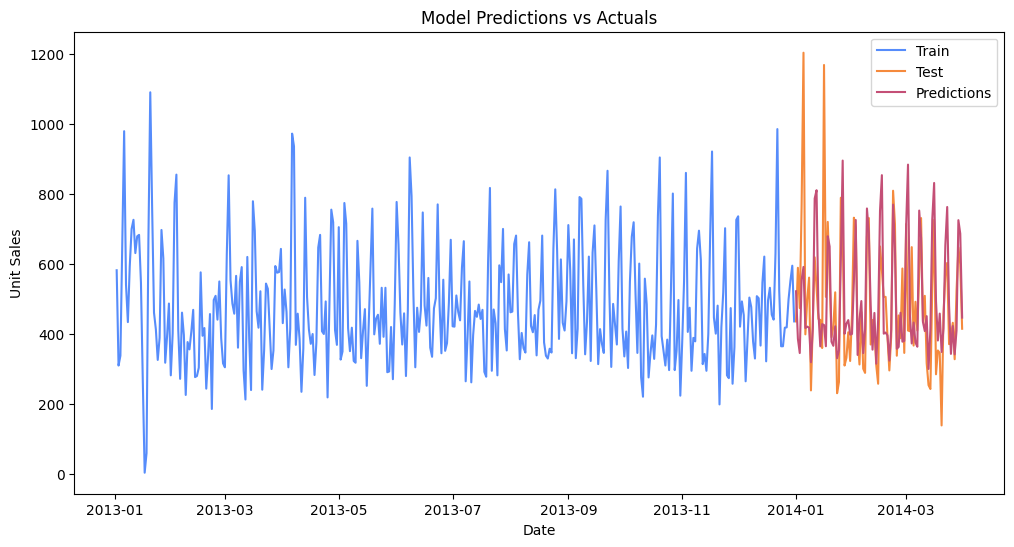

In [37]:

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f" MAE: {mae}, MSE: {mse}, R2: {r2}")
# visualize predictions against actuals and whole serie

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()


## Sklearn Models

In [40]:
# If you are using models that do not handle missing values, you can drop rows with NaN values in the training set
"""
X_train = X_train.dropna()
y_train = y_train[X_train.index]
"""



'\nX_train = X_train.dropna()\ny_train = y_train[X_train.index]\n'

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Initialize models
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42) # You can switch to LinearRegression() or SVR() to test other models

# Train the model
model.fit(X_train, y_train)
# Make predictions
forecast = iterative_forecast(model, train, len(X_test))
y_pred = forecast["unit_sales"]


In [39]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f" MAE: {mae}, MSE: {mse}, R2: {r2}")

 MAE: 96.9597051537387, MSE: 19500.257298038334, R2: 0.42075003642365005


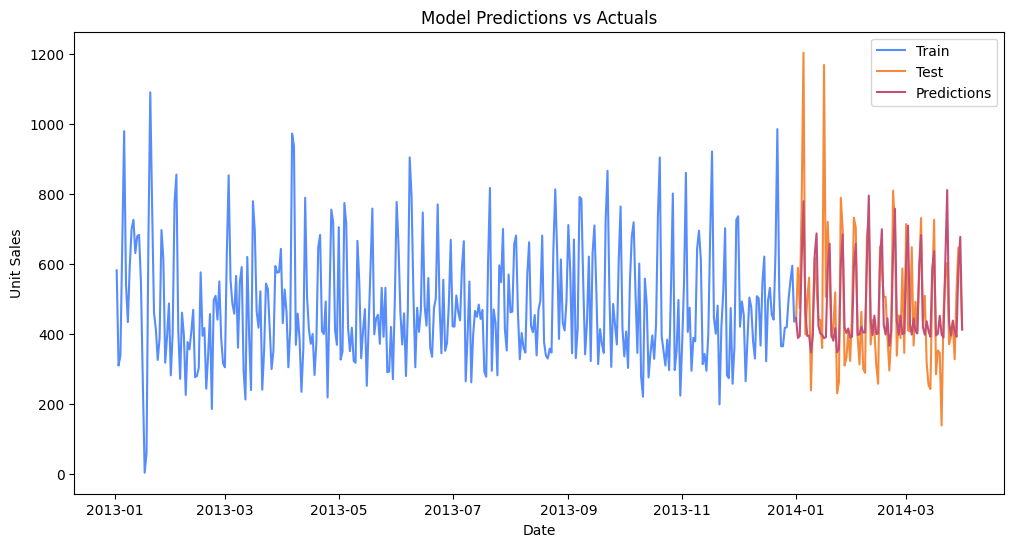

In [40]:
# visualize predictions against actuals and whole serie

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()
